## fxn/utils import

In [1]:
from jax import vmap
import jax
import time
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import jax.numpy as jnp
import jax.random as jr
from jax import vmap, jit, value_and_grad
import scipy.linalg as la
from scipy.linalg import orthogonal_procrustes


import optax
import time
import functools as ft
import matplotlib.pyplot as plt
import numpy as np
import time
from equinox_module import training_MODEL, create_FNN, save_MODEL, load_FNN

In [2]:
print("\nconfiguring backend...")
jax.config.update("jax_platform_name", "cpu")


print("backend selected:\n", jax.default_backend())
print("active devices:\n", jax.devices())
print("--------------------\n")


configuring backend...
Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB

backend selected:
 cpu
active devices:
 [CpuDevice(id=0)]
--------------------



W0000 00:00:1776865904.930506 36491486 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1776865904.954144 36491486 service.cc:145] XLA service 0x148db6890 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776865904.954293 36491486 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1776865904.958201 36491486 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1776865904.958214 36491486 mps_client.cc:384] XLA backend will use up to 11452858368 bytes on device 0 for SimpleAllocator.


In [3]:

def activation_fn_load(act_func):
    if act_func == 'tanh':
        activation = jnp.tanh
    if act_func == 'relu':
        activation = jax.nn.relu
    if act_func == 'swish':
        activation = jax.nn.swish
    if act_func == 'sine':
        activation = jnp.sin
    if act_func == 'cosine':
        activation = jnp.cos
    if act_func == 'gelu':
        activation = jax.nn.gelu
    return activation

class DeepONet(eqx.Module):
   trunk: eqx.nn.MLP
   branch: eqx.nn.MLP
   
   def __init__(
         self, 
         TRUNK_INPUT_DIM , TRUNK_OUTPUT_DIM , TRUNK_WIDTH , TRUNK_DEPTH , TRUNK_ACT ,
         BRANCH_INPUT_DIM, BRANCH_OUTPUT_DIM, BRANCH_WIDTH, BRANCH_DEPTH, BRANCH_ACT, 
         *, key
   ):
      key, subkey_trunk, subkey_branch = jr.split(key, num=3)
      self.trunk  = eqx.nn.MLP(in_size=TRUNK_INPUT_DIM , out_size=TRUNK_OUTPUT_DIM , width_size=TRUNK_WIDTH , depth=TRUNK_DEPTH , activation=activation_fn_load(TRUNK_ACT) , key=subkey_trunk)
      self.branch = eqx.nn.MLP(in_size=BRANCH_INPUT_DIM, out_size=BRANCH_OUTPUT_DIM, width_size=BRANCH_WIDTH, depth=BRANCH_DEPTH, activation=activation_fn_load(BRANCH_ACT), key=subkey_branch)

   def __call__(self, f, x):
      trunk  = jnp.concatenate([self.trunk(x),jnp.ones((1,))])
      branch = self.branch(f)
      return jnp.dot(trunk, branch)

def create_DeepONet(*, key, HYPER_MODEL):
    TRUNK_INPUT_DIM   = HYPER_MODEL["TRUNK"]["input_dim"]
    TRUNK_OUTPUT_DIM  = HYPER_MODEL["TRUNK"]["output_dim"]
    TRUNK_WIDTH       = HYPER_MODEL["TRUNK"]["width"]
    TRUNK_DEPTH       = HYPER_MODEL["TRUNK"]["depth"]
    TRUNK_ACT         = HYPER_MODEL["TRUNK"]["act_func"]
    BRANCH_INPUT_DIM  = HYPER_MODEL["BRANCH"]["input_dim"]
    BRANCH_OUTPUT_DIM = HYPER_MODEL["BRANCH"]["output_dim"]
    BRANCH_WIDTH      = HYPER_MODEL["BRANCH"]["width"]
    BRANCH_DEPTH      = HYPER_MODEL["BRANCH"]["depth"]
    BRANCH_ACT        = HYPER_MODEL["BRANCH"]["act_func"]
    model = DeepONet(key=key, 
                     TRUNK_INPUT_DIM=TRUNK_INPUT_DIM, 
                     TRUNK_OUTPUT_DIM=TRUNK_OUTPUT_DIM, 
                     TRUNK_WIDTH=TRUNK_WIDTH, 
                     TRUNK_DEPTH=TRUNK_DEPTH, 
                     TRUNK_ACT=TRUNK_ACT,
                     BRANCH_INPUT_DIM=BRANCH_INPUT_DIM, 
                     BRANCH_OUTPUT_DIM=BRANCH_OUTPUT_DIM, 
                     BRANCH_WIDTH=BRANCH_WIDTH, 
                     BRANCH_DEPTH=BRANCH_DEPTH, 
                     BRANCH_ACT=BRANCH_ACT)
    return model

def load_DeepONet(filename):
    with open(filename, "rb") as f:
        hyperparams = json.loads(f.readline().decode())
        model = create_DeepONet(key=jr.PRNGKey(0), HYPER_MODEL=hyperparams)
        return eqx.tree_deserialise_leaves(f, model)


def create_FNN(*, key, input_dim, output_dim, width, depth, act_func):
    activation = activation_fn_load(act_func)
    return eqx.nn.MLP(in_size=input_dim, out_size=output_dim, width_size=width, depth=depth, activation=activation, key=key)

def save_MODEL(filename, hyperparams, model):
    with open(filename, "wb") as f:
        hyperparam_str = json.dumps(hyperparams)
        f.write((hyperparam_str + "\n").encode())
        eqx.tree_serialise_leaves(f, model)

def load_FNN(filename):
    with open(filename, "rb") as f:
        hyperparams = json.loads(f.readline().decode())
        model = create_FNN(key=jr.PRNGKey(0), **hyperparams)
        return eqx.tree_deserialise_leaves(f, model)

def create_OPTIMIZER(optim_hyperparams):
    LR0   = optim_hyperparams['LEARNING_RATE_INITIAL']
    if optim_hyperparams['LEARNING_RATE_SCHEDULER'] == 'exponential':
        STEP  = optim_hyperparams['LEARNING_RATE_STEP']
        DECAY = optim_hyperparams['LEARNING_RATE_DECAY']
        LEARNING_RATE = optax.schedules.exponential_decay(LR0, STEP, DECAY)
    else:
        LEARNING_RATE = LR0
    
    OPTIM_NAME = optim_hyperparams['NAME']
    print(f'Selected Optimizer is [ {OPTIM_NAME} ], Initial Learning Rate is {LR0:1.2e}')
    if optim_hyperparams['LEARNING_RATE_SCHEDULER'] == 'exponential':
        print(f'You are using [ exponential ] learning rate scheduler with rate: {DECAY:.2f} and step: {STEP}')
    else:
        print(f'You are using [ constant ] learning rate')
            
    if OPTIM_NAME == 'adabelief':
        optimizer = optax.adabelief(LEARNING_RATE)
    if OPTIM_NAME == 'adadelta':
        optimizer = optax.adadelta(LEARNING_RATE)
    if OPTIM_NAME == 'adan':
        optimizer = optax.adan(LEARNING_RATE)
    if OPTIM_NAME == 'adafactor':
        optimizer = optax.adafactor(LEARNING_RATE)
    if OPTIM_NAME == 'adagrad':
        optimizer = optax.adagrad(LEARNING_RATE) 
    if OPTIM_NAME == 'adam':
        optimizer = optax.adam(LEARNING_RATE) 
    if OPTIM_NAME == 'adamw':
        optimizer = optax.adamw(LEARNING_RATE) 
    if OPTIM_NAME == 'adamax':
        optimizer = optax.adamax(LEARNING_RATE) 
    if OPTIM_NAME == 'adamaxw':
        optimizer = optax.adamaxw(LEARNING_RATE) 
    if OPTIM_NAME == 'amsgrad':
        optimizer = optax.amsgrad(LEARNING_RATE) 
    if OPTIM_NAME == 'lion':
        optimizer = optax.lion(LEARNING_RATE) 
    if OPTIM_NAME == 'nadam':
        optimizer = optax.nadam(LEARNING_RATE)
    if OPTIM_NAME == 'nadamw':
        optimizer = optax.nadamw(LEARNING_RATE) 
    if OPTIM_NAME == 'novograd':
        optimizer = optax.novograd(LEARNING_RATE) 
    if OPTIM_NAME == 'polyak_sgd':
        optimizer = optax.polyak_sgd(LEARNING_RATE)
    if OPTIM_NAME == 'radam':
        optimizer = optax.radam(LEARNING_RATE) 
    if OPTIM_NAME == 'rmsprop':
        optimizer = optax.rmsprop(LEARNING_RATE)
    if OPTIM_NAME == 'sgd':
        optimizer = optax.sgd(LEARNING_RATE) 
    if OPTIM_NAME == 'sm3':
        optimizer = optax.sm3(LEARNING_RATE)
    if OPTIM_NAME == 'yogi':
        optimizer = optax.yogi(LEARNING_RATE) 
         
    return optimizer


def training_MODEL(model, custom_loss_fn, HYPER_OPTIM):
  
  MAXITER     = HYPER_OPTIM['MAXITER']
  PRINT_EVERY = HYPER_OPTIM['PRINT_EVERY']
  optimizer  = create_OPTIMIZER(HYPER_OPTIM)
  opt_state  = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

  @eqx.filter_value_and_grad
  def loss_fn(model):
    return custom_loss_fn(model)

  @eqx.filter_jit
  def make_step(model, opt_state):
    lvalue, grads = loss_fn(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return lvalue, model, opt_state

  log_loss  = []
  log_minloss = []
  print(25*'-' + 'TRAINING STARTS' + 25*'-')
  print(65*'-')
  start_time = time.time()
  for epoch in range(MAXITER):
      current_loss, model, opt_state = make_step(model, opt_state)
      log_loss.append(current_loss)
      if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
      else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
      if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
            print(f"Epoch {epoch//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          else:
            print(f"Epoch {epoch:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()

  current_loss, _ = loss_fn(model)
  log_loss.append(current_loss)        
  if current_loss < log_minloss[-1]:
    minloss = current_loss
    model_opt = model
  else:
    minloss = log_minloss[-1]
  log_minloss.append(minloss)
  end_time = time.time()
  if PRINT_EVERY >= 1000:
    print(f"Epoch {MAXITER//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  else:
    print(f"Epoch {MAXITER:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  
  
  if HYPER_OPTIM['LBFGS']['USE'] == 'on':
      params, static = eqx.partition(model_opt, eqx.is_array)
      optim = optax.lbfgs()
      opt_state = optim.init(params)
    
      @eqx.filter_jit
      def loss_fn_LBFGS(params):
        model = eqx.combine(params, static)
        return custom_loss_fn(model)

      @eqx.filter_jit
      def make_step_bfgs(params, opt_state):
        loss, grads = eqx.filter_value_and_grad(loss_fn_LBFGS)(params)

        updates, opt_state = optim.update(
                grads, 
                opt_state,
                params,
                value=loss,
                grad=grads,
                value_fn=loss_fn_LBFGS
            )

        params = eqx.apply_updates(params, updates)
        return loss, params, opt_state
    
      # Training Loop 
      MAXITER     = HYPER_OPTIM['LBFGS']['MAXITER']
      PRINT_EVERY = HYPER_OPTIM['LBFGS']['PRINT_EVERY']
      print(65*'-')
      print(21*'-' + '[LBFGS] TRAINING STARTS' + 21*'-')
      print(25*'-' + f' MAXITER= {MAXITER} ' + 25*'-')
      start_time  = time.time()
      for epoch in range(MAXITER):
        model = eqx.combine(params, static)
        current_loss, params, opt_state = make_step_bfgs(params, opt_state)
        log_loss.append(current_loss)
        if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
        else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
        if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
             print(f"[LBFGS] Ep {epoch//1000:3d}K: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          else:
             print(f"[LBFGS] Ep {epoch:3d}: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()
          
      model = eqx.combine(params, static)
      current_loss, _ = loss_fn(model)
      log_loss.append(current_loss)        
      if current_loss < log_minloss[-1]:
          minloss = current_loss
          model_opt = model
      else:
          minloss = log_minloss[-1]
          log_minloss.append(minloss)
      end_time = time.time()
      if PRINT_EVERY >= 1000:
          print(f"[LBFGS] Ep {MAXITER//1000:3d}K: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
      else:
          print(f"[LBFGS] Ep{MAXITER:3d}: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
    
  return model_opt, log_loss, log_minloss



def training_MODEL_RBA(model, custom_loss_fn, custom_loss_fn_LBFGS, HYPER_OPTIM, HYPER_RBA):
  
  MAXITER     = HYPER_OPTIM['MAXITER']
  PRINT_EVERY = HYPER_OPTIM['PRINT_EVERY']
  optimizer  = create_OPTIMIZER(HYPER_OPTIM)
  opt_state  = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

  RBA_lambda = HYPER_RBA['RBA_lambda']
  
#   @eqx.filter_value_and_grad
  @eqx.filter_jit
  def loss_fn(model,RBA_lambda):
    return custom_loss_fn(model,RBA_lambda)

  @eqx.filter_jit
  def make_step(model, opt_state, RBA_lambda):
    loss_fn_RBA = ft.partial(loss_fn, RBA_lambda=RBA_lambda)
    (_, (RBA_lambda,lvalue)), grads = eqx.filter_value_and_grad(loss_fn_RBA, has_aux=True)(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return lvalue, model, opt_state, RBA_lambda

  log_loss  = []
  log_minloss = []
  print(25*'-' + 'TRAINING STARTS' + 25*'-')
  print(65*'-')
  start_time = time.time()
  for epoch in range(MAXITER):
      current_loss, model, opt_state, RBA_lambda = make_step(model, opt_state, RBA_lambda)
      log_loss.append(current_loss)
      if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
      else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
      if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
            print(f"Epoch {epoch//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          else:
            print(f"Epoch {epoch:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()

  current_loss = loss_fn(model,RBA_lambda)[1][1]
  log_loss.append(current_loss)        
  if current_loss < log_minloss[-1]:
    minloss = current_loss
    model_opt = model
  else:
    minloss = log_minloss[-1]
  log_minloss.append(minloss)
  end_time = time.time()
  if PRINT_EVERY >= 1000:
    print(f"Epoch {MAXITER//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  else:
    print(f"Epoch {MAXITER:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  
  
  if HYPER_OPTIM['LBFGS']['USE'] == 'on':
      params, static = eqx.partition(model_opt, eqx.is_array)
      optim = optax.lbfgs()
      opt_state = optim.init(params)
    
      @eqx.filter_jit
      def loss_fn_LBFGS(params):
        model = eqx.combine(params, static)
        return ft.partial(custom_loss_fn_LBFGS, RBA_lambda=RBA_lambda)(model)

      @eqx.filter_jit
      def make_step_bfgs(params, opt_state):
        loss, grads = eqx.filter_value_and_grad(loss_fn_LBFGS)(params)

        updates, opt_state = optim.update(
                grads, 
                opt_state,
                params,
                value=loss,
                grad=grads,
                value_fn=loss_fn_LBFGS
            )

        params = eqx.apply_updates(params, updates)
        return loss, params, opt_state
    
      # Training Loop 
      MAXITER     = HYPER_OPTIM['LBFGS']['MAXITER']
      PRINT_EVERY = HYPER_OPTIM['LBFGS']['PRINT_EVERY']
      print(65*'-')
      print(21*'-' + '[LBFGS] TRAINING STARTS' + 21*'-')
      print(25*'-' + f' MAXITER= {MAXITER} ' + 25*'-')
      start_time  = time.time()
      for epoch in range(MAXITER):
        model = eqx.combine(params, static)
        current_loss, params, opt_state = make_step_bfgs(params, opt_state)
        log_loss.append(current_loss)
        if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
        else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
        if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
             print(f"[LBFGS] Ep {epoch//1000:3d}K: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          else:
             print(f"[LBFGS] Ep {epoch:3d}: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()
          
      model = eqx.combine(params, static)
      current_loss = loss_fn(model,RBA_lambda)[1][1]
      log_loss.append(current_loss)        
      if current_loss < log_minloss[-1]:
          minloss = current_loss
          model_opt = model
      else:
          minloss = log_minloss[-1]
          log_minloss.append(minloss)
      end_time = time.time()
      if PRINT_EVERY >= 1000:
          print(f"[LBFGS] Ep {MAXITER//1000:3d}K: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
      else:
          print(f"[LBFGS] Ep{MAXITER:3d}: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
    
  return model_opt, log_loss, log_minloss

## load data

In [4]:
test_data = jnp.load("hw4_burgers_test_data.npz")
train_data = jnp.load("hw4_burgers_train_data.npz")

test_xt, test_u, test_params = test_data["xt_grid"], test_data["u_sol"], test_data["params"]
train_xt, train_u, train_params = train_data["xt_grid"], train_data["u_sol"], train_data["params"]

x_grid = jnp.unique(train_xt[:, 0])
t_grid = jnp.unique(train_xt[:, 1])

U_3d = np.array(train_u).reshape(train_u.shape[0], len(x_grid), len(t_grid)).transpose(2, 1, 0)  # (T, X, N)

## deeponet definition


In [5]:
SEED = 77

# per assignment
BRANCH_INPUT_DIM  = 3 ## NOW INCLUDES TIME
BRANCH_WIDTH      = 100
BRANCH_DEPTH      = 4
BRANCH_ACTIVATION = 'tanh'

TRUNK_INPUT_DIM   = 2
TRUNK_WIDTH       = 16
TRUNK_DEPTH       = 6
TRUNK_ACTIVATION  = 'gelu'

DEEPONET_WIDTH    = 6
# sine, cosine, relu, tanh, gelu, swish


LEARNING_RATE = 1e-3
OPTIMIZER_NAME = 'adam'
# adabelief, adadelta, adan, adafactor, adagrad, adam, adamw,
# adamax, adamaxw, amsgrad, lion, nadam, nadamw, novograd, radam,
# rmsprop, sgd, sm3, yogi, polyak_sgd
MAXITER = 20_000
PRINT_EVERY = 1_000

LR_SCHEDULER = 'exponential' #'constant' # exponential or constant
LR_DECAY = 0.95
LR_STEP  = 3000

LBFGS_USE = 'off'
LBFGS_MAXITER = 10_000
LBFGS_PRINT_EVERY = 1_000
if LBFGS_USE != 'on':
    LBFGS_MAXITER = 0
    LBFGS_PRINT_EVERY = 0

In [6]:
HYPER_MODEL = {"TRUNK": {"input_dim": TRUNK_INPUT_DIM, 
               "output_dim": DEEPONET_WIDTH, 
               "width": TRUNK_WIDTH,
               "depth": TRUNK_DEPTH-1, 
               "act_func": TRUNK_ACTIVATION},
               "BRANCH": {"input_dim": BRANCH_INPUT_DIM, 
               "output_dim": DEEPONET_WIDTH+1, 
               "width": BRANCH_WIDTH,
               "depth": BRANCH_DEPTH-1, 
               "act_func": BRANCH_ACTIVATION}
            }

HYPER_OPTIM = {"MAXITER": MAXITER, 
               "NAME": OPTIMIZER_NAME, 
               "LEARNING_RATE_SCHEDULER": LR_SCHEDULER, 
               "LEARNING_RATE_INITIAL": LEARNING_RATE, 
               "LEARNING_RATE_DECAY": LR_DECAY, 
               "LEARNING_RATE_STEP": LR_STEP, 
               "PRINT_EVERY": PRINT_EVERY,
               "LBFGS": {"USE": LBFGS_USE, "MAXITER": LBFGS_MAXITER, "PRINT_EVERY": LBFGS_PRINT_EVERY}
               }

In [7]:
key = jr.PRNGKey(SEED)
key, subkey_model_trunk, subkey_model_A, subkey_model_branch, subkey_w, subkey_w_test = jr.split(key, num=6)

In [8]:
model_trunk = create_FNN(key=subkey_model_trunk, **HYPER_MODEL["TRUNK"])

In [9]:
model_A = jnp.zeros((len(t_grid), DEEPONET_WIDTH, train_u.shape[0]))  # (T, K, N)
print(model_A.shape)
model       = model_trunk, model_A

(201, 6, 25)


## loss fn and training

### trunk network

In [10]:
def loss_fn(model):
    model_trunk, model_A = model
    trunk_out_flat = vmap(lambda x: model_trunk(x))(train_xt)  # (T*X, K)
    trunk_out = trunk_out_flat.reshape(len(t_grid), len(x_grid), -1)  # (T, X, K) -- no transpose, t-major reshape
    model_out = jnp.einsum("txk, tkn -> txn", trunk_out, model_A)
    u_train_flat = jnp.array(U_3d)  # use corrected U_3d
    residual = model_out - u_train_flat
    return jnp.mean(residual**2)

In [11]:
start_time = time.time()
model, log_loss, log_minloss = training_MODEL(model, loss_fn, HYPER_OPTIM)
end_time = time.time()

Selected Optimizer is [ adam ], Initial Learning Rate is 1.00e-03
You are using [ exponential ] learning rate scheduler with rate: 0.95 and step: 3000
-------------------------TRAINING STARTS-------------------------
-----------------------------------------------------------------
Epoch   0K: loss = 1.5688e-01, minloss = 1.5688e-01, Time: 0.45s
Epoch   1K: loss = 2.1005e-04, minloss = 2.1005e-04, Time: 9.14s
Epoch   2K: loss = 3.2639e-05, minloss = 3.2639e-05, Time: 9.20s
Epoch   3K: loss = 1.3173e-05, minloss = 1.3173e-05, Time: 9.58s
Epoch   4K: loss = 7.2394e-06, minloss = 7.2394e-06, Time: 9.15s
Epoch   5K: loss = 5.0159e-06, minloss = 5.0159e-06, Time: 9.21s
Epoch   6K: loss = 3.8565e-06, minloss = 3.8565e-06, Time: 9.47s
Epoch   7K: loss = 2.9109e-06, minloss = 2.9109e-06, Time: 9.30s
Epoch   8K: loss = 2.0170e-06, minloss = 2.0170e-06, Time: 8.97s
Epoch   9K: loss = 1.4269e-06, minloss = 1.3919e-06, Time: 8.97s
Epoch  10K: loss = 1.0324e-06, minloss = 1.0324e-06, Time: 9.06s
Ep

In [12]:
T_MAT = jnp.concatenate([vmap(lambda x: model_trunk(x))(train_xt), jnp.ones([train_xt.shape[0],1])], axis=1)
print(T_MAT.shape)  # should be (T*X, K+1)

T_MAT_3d = T_MAT.reshape(len(x_grid), len(t_grid), -1).transpose(1, 0, 2)  # (T, X, K+1)
print(T_MAT_3d.shape)  # should be (T, X, K+1)

(40401, 7)
(201, 201, 7)


In [13]:
# T_MAT_3d = T_MAT.reshape(len(t_grid), len(x_grid), -1)  # (X, T, K+1)

# ## ADDING
# T_MAT_3d = T_MAT_3d.transpose(1, 0, 2)  # (T, X, K+1)

# data is X major
T_MAT_3d = T_MAT.reshape(len(x_grid), len(t_grid), -1).transpose(1, 0, 2)  # (T, X, K+1)

Q_ref, _ = la.qr(np.mean(T_MAT_3d, axis=1), mode='economic')  # (X, K+1)

Q_sign = None
R_sign = None


LOOKBACK = 5  # number of previous frames to average

# for i in range(len(t_grid)):
#     Q, R = la.qr(np.array(T_MAT_3d[i, :, :]), mode='economic')
    
#     if i == 0:
#         Q_sign = Q[np.newaxis]
#         R_sign = R[np.newaxis]
#     else:
#         # average over last LOOKBACK frames as reference
#         start = max(0, i - LOOKBACK)
#         Q_ref = np.mean(Q_sign[start:i], axis=0)  # (X, K+1)
        
#         for j in range(Q.shape[1]):
#             overlap = np.dot(Q_ref[:, j], Q[:, j])
#             sign = np.sign(overlap) if np.abs(overlap) > 1e-10 else 1.0
#             Q[:, j] *= sign
#             R[j, :] *= sign
        
#         Q_sign = np.concatenate([Q_sign, Q[np.newaxis]], axis=0)
#         R_sign = np.concatenate([R_sign, R[np.newaxis]], axis=0)



# apply smoothing to Q
for i in range(len(t_grid)):
    Q, R = la.qr(np.array(T_MAT_3d[i, :, :]), mode='economic')  # QR of (X, K+1)
    
    if i == 0:
        Q_sign = Q[np.newaxis]
        R_sign = R[np.newaxis]
    else:
        for j in range(Q.shape[1]):
            overlap = np.dot(Q_sign[-1, :, j], Q[:, j])
            sign = np.sign(overlap) if np.abs(overlap) > 1e-10 else 1.0
            Q[:, j] *= sign
            R[j, :] *= sign
        Q_sign = np.concatenate([Q_sign, Q[np.newaxis]], axis=0)
        R_sign = np.concatenate([R_sign, R[np.newaxis]], axis=0)


R_procs = [None] * len(t_grid)
Q_smooth = Q_sign.copy()
for i in range(1, len(t_grid)):
    R_proc, _ = orthogonal_procrustes(Q_smooth[i], Q_smooth[i-1])
    Q_smooth[i] = Q_smooth[i] @ R_proc
    R_procs[i] = R_proc

R_smooth = R_sign.copy()
R_smooth[0] = R_sign[0]
for i in range(1, len(t_grid)):
    R_smooth[i] = R_procs[i].T @ R_sign[i]

# apply smoothing to R
# for i in range(len(t_grid)):
#     Q, R = la.qr(np.array(T_MAT_3d[i, :, :]), mode='economic')
    
#     if i == 0:
#         Q_sign = Q[np.newaxis]
#         R_sign = R[np.newaxis]
#     else:
#         for j in range(Q.shape[1]):
#             overlap = np.dot(Q_sign[-1, :, j], Q[:, j])
#             sign = np.sign(overlap) if np.abs(overlap) > 1e-10 else 1.0
#             Q[:, j] *= sign
#             R[j, :] *= sign
#         Q_sign = np.concatenate([Q_sign, Q[np.newaxis]], axis=0)
#         R_sign = np.concatenate([R_sign, R[np.newaxis]], axis=0)


# R_procs = [None] * len(t_grid)
# R_smooth = R_sign.copy()
# Q_smooth = Q_sign.copy()
# for i in range(1, len(t_grid)):
#     R_proc, _ = orthogonal_procrustes(R_smooth[i], R_smooth[i-1])
#     R_smooth[i] = R_smooth[i] @ R_proc
#     Q_smooth[i] = Q_smooth[i] @ R_proc.T
#     R_procs[i] = R_proc

In [14]:
A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]
res = np.max(np.abs(T_MAT_3d[i] @ A_t - U_3d[i]))
print(f"t=160 lstsq residual: {res:.4e}")

t=160 lstsq residual: 1.5832e-08


In [15]:
for i in range(0, len(t_grid), 20):
    A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]
    res = np.max(np.abs(T_MAT_3d[i] @ A_t - U_3d[i]))
    print(f"t={i} lstsq residual: {res:.4e}")

t=0 lstsq residual: 9.3132e-09
t=20 lstsq residual: 1.3784e-07
t=40 lstsq residual: 6.3032e-06
t=60 lstsq residual: 8.1807e-05
t=80 lstsq residual: 2.1821e-04
t=100 lstsq residual: 1.2419e-03
t=120 lstsq residual: 3.8636e-03
t=140 lstsq residual: 2.3203e-02
t=160 lstsq residual: 8.7852e-02
t=180 lstsq residual: 7.9721e-07
t=200 lstsq residual: 1.5832e-08


In [16]:
print(DEEPONET_WIDTH)
print(HYPER_MODEL)

6
{'TRUNK': {'input_dim': 2, 'output_dim': 6, 'width': 16, 'depth': 5, 'act_func': 'gelu'}, 'BRANCH': {'input_dim': 3, 'output_dim': 7, 'width': 100, 'depth': 3, 'act_func': 'tanh'}}


In [17]:
print(train_u.shape)

(25, 40401)


In [18]:
# lsq_A per time step: solve T_MAT_3d[t] @ A[t] = U_true for each t

RA_target = np.random.randn(len(t_grid), Q_sign.shape[2], train_u.shape[0]) * 1e-3
for i in range(len(t_grid)):
    A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]
    RA_target[i] = R_smooth[i] @ A_t

RA_target = jnp.array(RA_target)
RA_scale = np.std(np.array(RA_target), axis=(0, 2), keepdims=True) + 1e-8  # (1, K+1, 1)

In [19]:
# reconstruct: Q_sign (T, X, K+1) @ R_sign (T, K+1, K+1) @ A_t should give U_3d
recon = np.einsum("txk,tkj->txj", Q_sign, R_sign)
T_MAT_check = T_MAT_3d  # (T, X, K+1)
print("QR reconstruction error:", np.max(np.abs(recon - T_MAT_check)))

# also check that Q_sign @ R_sign @ A recovers U
A_check = np.zeros((len(t_grid), Q_sign.shape[2], train_u.shape[0]))
for i in range(len(t_grid)):
    A_check[i] = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]

recon_U = np.einsum("txk,tkn->txn", Q_sign, R_sign @ A_check if False else 
                    np.array([R_sign[i] @ A_check[i] for i in range(len(t_grid))]))
print("U reconstruction error:", np.max(np.abs(recon_U - U_3d)))

QR reconstruction error: 2.4497509e-05
U reconstruction error: 0.32363945808419997


In [20]:
# check lstsq residual at a single time step
i = 0
A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]  # (K+1, N)
recon_slice = T_MAT_3d[i, :, :] @ A_t  # (X, N)
print("lstsq residual at t=0:", np.max(np.abs(recon_slice - U_3d[i])))

# check that R @ A recovers Q^T @ U
QTA = Q_sign[i].T @ U_3d[i]  # (K+1, N)
RA  = R_sign[i] @ A_t         # (K+1, N)
print("RA vs Q^T U error:", np.max(np.abs(RA - QTA)))

lstsq residual at t=0: 9.313226e-09
RA vs Q^T U error: 4.3074054723035715e-07


In [21]:
print(T_MAT_3d.shape)
print(Q_sign.shape)
print(R_sign.shape)

(201, 201, 7)
(201, 201, 7)
(201, 7, 7)


In [22]:
# check single time step QR reconstruction
i = 0
print(np.max(np.abs(Q_sign[i] @ R_sign[i] - T_MAT_3d[i])))
i = 100
print(np.max(np.abs(Q_sign[i] @ R_sign[i] - T_MAT_3d[i])))
i = 160
print(np.max(np.abs(Q_sign[i] @ R_sign[i] - T_MAT_3d[i])))

2.1457672e-05
4.172325e-06
5.00679e-06


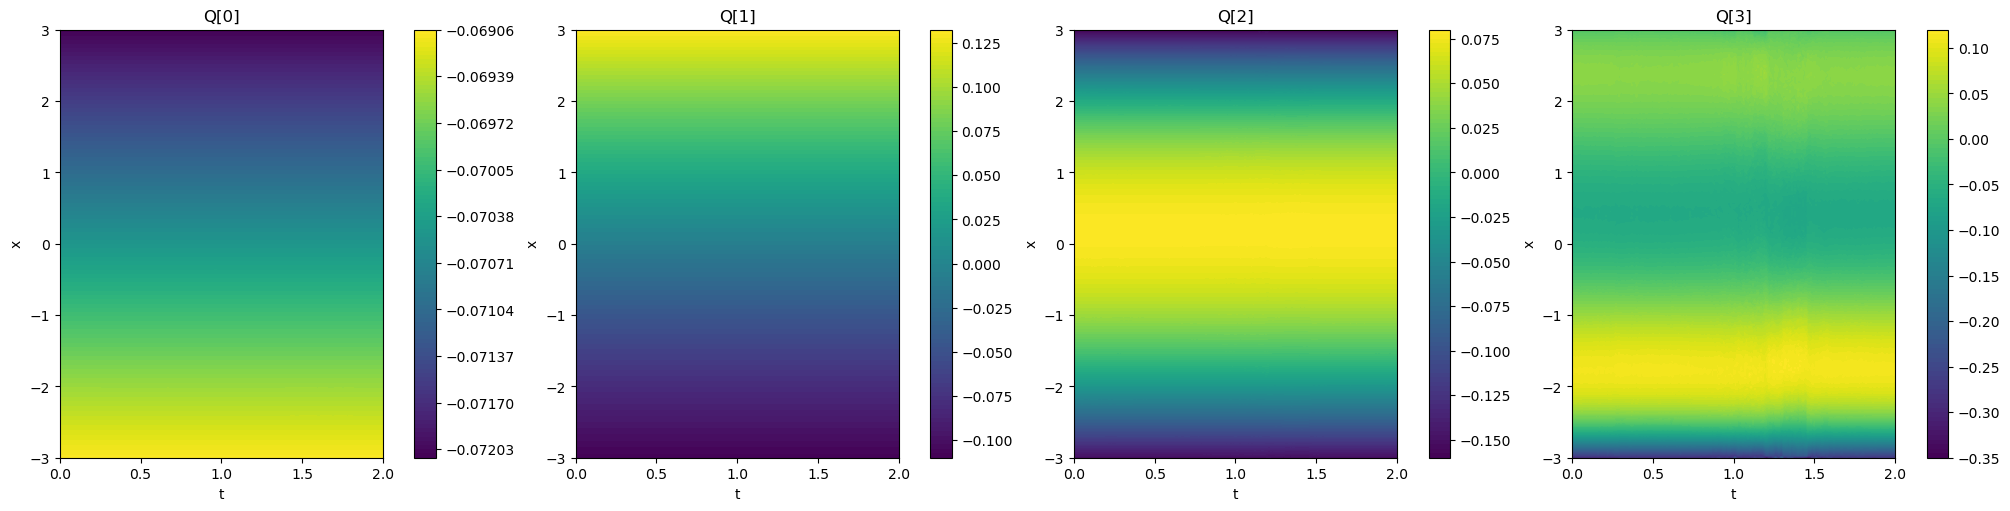

In [23]:
num_bases = 4
ncols = 4
nrows = int(np.ceil(num_bases / ncols))
T, X  = np.meshgrid(t_grid, x_grid, indexing="ij")

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)
axes = axes.flatten()

for k, ax in enumerate(axes):
    if k < num_bases:
        Q_k = Q_smooth[:, :, k]
        im  = ax.contourf(T, X, Q_k, levels=100, cmap='viridis')
        ax.set_title(f"Q[{k}]")
        ax.set_xlabel("t")
        ax.set_ylabel("x")
        fig.colorbar(im, ax=ax)
    else:
        ax.axis("off")

In [24]:
# lsq_A per time step: solve T_MAT_3d[t] @ A[t] = U_true for each t

RA_target = np.random.randn(len(t_grid), Q_sign.shape[2], train_u.shape[0]) * 1e-3
for i in range(len(t_grid)):
    A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]
    RA_target[i] = R_smooth[i] @ A_t

RA_target = jnp.array(RA_target)
RA_scale = np.std(np.array(RA_target), axis=(0, 2), keepdims=True) + 1e-8  # (1, K+1, 1)

### branch network

In [25]:
model_branch= create_FNN(key=subkey_model_branch, **HYPER_MODEL["BRANCH"])

LEARNING_RATE = 1e-3
OPTIMIZER_NAME = 'adam'
# adabelief, adadelta, adan, adafactor, adagrad, adam, adamw,
# adamax, adamaxw, amsgrad, lion, nadam, nadamw, novograd, radam,
# rmsprop, sgd, sm3, yogi, polyak_sgd
MAXITER = 100_000
PRINT_EVERY = 10_000

LR_SCHEDULER = 'exponential' # exponential or constant
LR_DECAY = 0.95
LR_STEP  = 15_000

LBFGS_USE = 'off'
LBFGS_MAXITER = 10_000
LBFGS_PRINT_EVERY = 1_00
if LBFGS_USE != 'on':
    LBFGS_MAXITER = 0
    LBFGS_PRINT_EVERY = 0
    
HYPER_OPTIM_Branch = {"MAXITER": MAXITER, 
               "NAME": OPTIMIZER_NAME, 
               "LEARNING_RATE_SCHEDULER": LR_SCHEDULER, 
               "LEARNING_RATE_INITIAL": LEARNING_RATE, 
               "LEARNING_RATE_DECAY": LR_DECAY, 
               "LEARNING_RATE_STEP": LR_STEP, 
               "PRINT_EVERY": PRINT_EVERY,
               "LBFGS": {"USE": LBFGS_USE, "MAXITER": LBFGS_MAXITER, "PRINT_EVERY": LBFGS_PRINT_EVERY}
               }


In [26]:
# scaling RA

# RA_scale = np.std(RA_target, axis=(0, 2), keepdims=True) + 1e-8  # (1, K+1, 1)
# RA_target_normed = RA_target / RA_scale


# updating branch_loss_fn

#RA_target_jnp = jnp.array(RA_target_normed)
RA_target_jnp = jnp.array(RA_target)

# weight inversely proportional to t, emphasizing early times
t_weights = 1.0 / (jnp.array(t_grid) + t_grid[1])  # avoid div by zero at t=0
t_weights = t_weights / t_weights.mean()  # normalize so overall scale is preserved

def branch_loss_fn(model):
    B_tnK = vmap(
        lambda t_val: vmap(
            lambda u: model(jnp.concatenate([u, jnp.array([t_val])]))
        )(train_params)
    )(t_grid)
    B_MAT = jnp.swapaxes(B_tnK, 1, 2)  # (T, K+1, N)
    residual = (B_MAT - RA_target_jnp) ** 2  # (T, K+1, N)
    return jnp.mean(residual * t_weights[:, None, None])

In [27]:
# def branch_loss_fn(model):
#     B_tnK = vmap(
#         lambda t_val: vmap(
#             lambda u: model(jnp.concatenate([u, jnp.array([t_val])]))
#         )(train_params)
#     )(t_grid)                          # (T, N, K+1)
#     B_MAT = jnp.swapaxes(B_tnK, 1, 2) # (T, K+1, N)
#     return jnp.mean((B_MAT - RA_target) ** 2)

start_time = time.time()
model_branch, log_loss_branch, log_minloss_branch = training_MODEL(model_branch, branch_loss_fn, HYPER_OPTIM_Branch)
end_time = time.time()

Selected Optimizer is [ adam ], Initial Learning Rate is 1.00e-03
You are using [ exponential ] learning rate scheduler with rate: 0.95 and step: 15000
-------------------------TRAINING STARTS-------------------------
-----------------------------------------------------------------
Epoch   0K: loss = 1.3692e+00, minloss = 1.3692e+00, Time: 0.17s
Epoch  10K: loss = 4.6900e-05, minloss = 4.0903e-05, Time: 49.12s
Epoch  20K: loss = 3.4638e-05, minloss = 3.4552e-05, Time: 50.56s
Epoch  30K: loss = 3.8659e-05, minloss = 3.2821e-05, Time: 49.45s
Epoch  40K: loss = 3.2577e-05, minloss = 3.1171e-05, Time: 49.91s
Epoch  50K: loss = 3.9443e-05, minloss = 3.0138e-05, Time: 49.31s
Epoch  60K: loss = 3.3917e-05, minloss = 2.9227e-05, Time: 48.61s
Epoch  70K: loss = 3.2890e-05, minloss = 2.8589e-05, Time: 49.88s
Epoch  80K: loss = 3.2389e-05, minloss = 2.7978e-05, Time: 50.75s
Epoch  90K: loss = 4.9511e-05, minloss = 2.7459e-05, Time: 49.64s
Epoch 100K: loss = 2.6818e-05, minloss = 2.6784e-05, Time

In [28]:
for i in np.arange(0, len(t_grid)//2, -1):
    A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]
    res = np.max(np.abs(T_MAT_3d[i] @ A_t - U_3d[i]))
    print(f"t={i} lstsq residual: {res:.4e}")

In [29]:
print("RA_target std per t, k=0:", np.std(RA_target[:, 0, :], axis=1))
print("RA_target mean abs per t, k=0:", np.mean(np.abs(RA_target[:, 0, :]), axis=1))

RA_target std per t, k=0: [0.02858462 0.02887581 0.03107121 0.03342441 0.03590799 0.0385242
 0.04127497 0.04416167 0.04718554 0.05034655 0.05364451 0.05707897
 0.06064769 0.06434879 0.06817914 0.07213513 0.07621176 0.08040539
 0.0847085  0.08911534 0.0936186  0.0982106  0.10288256 0.10762557
 0.11243025 0.11728758 0.12218601 0.12711482 0.13206516 0.1370249
 0.14198731 0.14692888 0.15185128 0.15673538 0.16157019 0.16636698
 0.1710919  0.17572999 0.1802816  0.18474315 0.18911871 0.19337271
 0.19750454 0.20154399 0.2054167  0.20916569 0.2127925  0.21625234
 0.21958646 0.22276889 0.22582243 0.22871627 0.23140764 0.23404449
 0.23646118 0.23879579 0.24094254 0.242999   0.24487102 0.24662177
 0.24825154 0.24976774 0.2511983  0.2525245  0.25374737 0.25489655
 0.25596443 0.25699022 0.25792673 0.25886023 0.25971073 0.26056284
 0.2614749  0.26231542 0.2631334  0.26401746 0.26494128 0.2661398
 0.26723    0.26815453 0.26938885 0.27074942 0.27207187 0.27380484
 0.2752831  0.27697998 0.27893773 0.281

In [30]:
print("RA_target mean:", np.mean(np.abs(RA_target)))
print("RA_target max:", np.max(np.abs(RA_target)))
print("RA_target std per k:", np.std(RA_target, axis=(0,2)))  # variation across k modes

RA_target mean: 0.74778616
RA_target max: 10.49409
RA_target std per k: [3.5811698  1.0145512  0.32912594 0.08073398 0.12534235 0.0400932
 0.03378522]


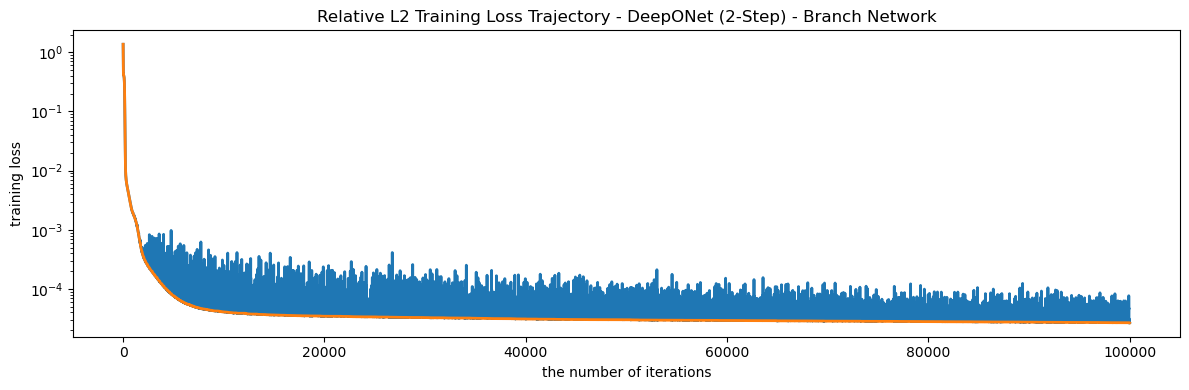

In [31]:

# print(NN_pred_final.shape)
# rel_l2_error = jnp.sqrt(jnp.sum((test_u - NN_pred_final)**2,axis=1) / jnp.sum(test_u**2,axis=1))
# print(f"Avg. Relative L2 error     : {jnp.mean(rel_l2_error):.4e}")



plt.figure(figsize = (12,4))
plt.semilogy(log_loss_branch, linewidth = 2)
plt.semilogy(log_minloss_branch, linewidth =2)
plt.xlabel('the number of iterations')
plt.ylabel('training loss')
plt.title("Relative L2 Training Loss Trajectory - DeepONet (2-Step) - Branch Network")
plt.tight_layout()
# plt.suptitle(title_str + '\n')
plt.savefig("deeponet_2step_training_branch.png")
plt.show()

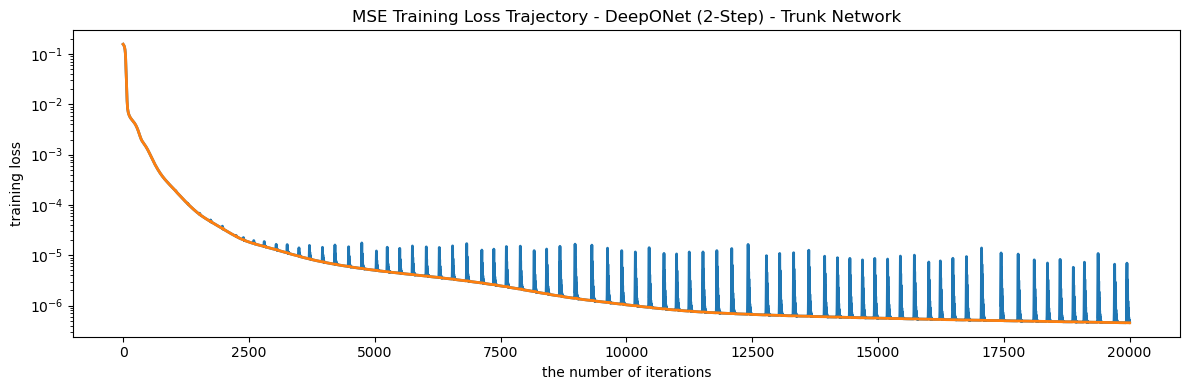

In [32]:

# print(NN_pred_final.shape)
# rel_l2_error = jnp.sqrt(jnp.sum((test_u - NN_pred_final)**2,axis=1) / jnp.sum(test_u**2,axis=1))
# print(f"Avg. MSE error     : {jnp.mean(rel_l2_error):.4e}")



plt.figure(figsize = (12,4))
plt.semilogy(log_loss, linewidth = 2)
plt.semilogy(log_minloss, linewidth =2)
plt.xlabel('the number of iterations')
plt.ylabel('training loss')
plt.title("MSE Training Loss Trajectory - DeepONet (2-Step) - Trunk Network")
plt.tight_layout()
# plt.suptitle(title_str + '\n')
plt.savefig("deeponet_2step_training.png")
plt.show()

In [33]:
np.savez('td_loss_hist.npz', log_loss, log_minloss, log_loss_branch, log_minloss_branch, labels = ['log_loss_td', 'log_minloss_td', 'log_loss_branch_td', 'log_minloss_branch_td'])

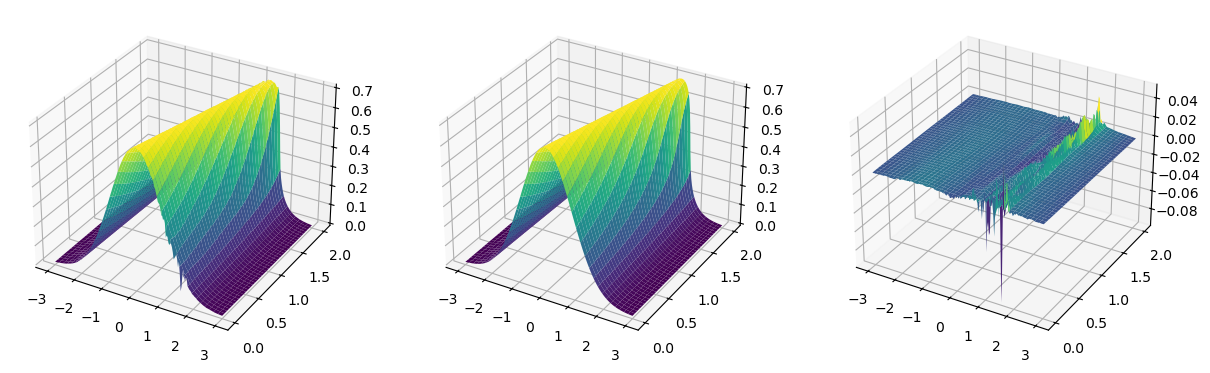

In [34]:
# rescaled RA target

#RA_scale_jnp = jnp.array(RA_scale[0, :, 0])  # (K+1,)

def predict_one(u):
    b_tk = vmap(lambda t_val: model_branch(jnp.concatenate([u, jnp.array([t_val])])))(t_grid)  # (T, K+1)
    #b_tk = b_tk * RA_scale_jnp  # rescale
    return jnp.einsum("txk,tk->tx", jnp.array(Q_smooth), b_tk)

NN_pred_final = vmap(predict_one)(test_params)  # (N, T, X)

pred  = NN_pred_final[0]          # (T, X)
truth = test_u[0].reshape(len(x_grid), len(t_grid))

T_plot, X_plot = np.meshgrid(t_grid, x_grid, indexing="ij")  # (T, X)
truth = train_u[0].reshape(len(x_grid), len(t_grid)).T  # (T, X)

pred  = NN_pred_final[0]                                    # (T, X)


fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw=dict(projection='3d'))





x_plot = train_xt[:, 0].reshape(len(x_grid), len(t_grid))
t_plot = train_xt[:, 1].reshape(len(x_grid), len(t_grid))

truth = train_u[0].reshape(len(x_grid), len(t_grid))
pred  = NN_pred_final[0].T  # your pred is (T, X), transpose to (X, T)

axes[0].plot_surface(x_plot, t_plot, pred, cmap="viridis")
axes[1].plot_surface(x_plot, t_plot, truth, cmap="viridis")
axes[2].plot_surface(x_plot, t_plot, pred - truth, cmap="viridis")


In [35]:
print(train_xt[:5])  # is it t-major or x-major?
print(train_u.shape)  # (N, T*X) or (N, X*T)?

[[-3.    0.  ]
 [-2.97  0.  ]
 [-2.94  0.  ]
 [-2.91  0.  ]
 [-2.88  0.  ]]
(25, 40401)


In [36]:
jnp.mean((pred - truth)**2)

Array(7.2100174e-06, dtype=float32)

In [37]:
# loaded_model = load_DeepONet('DeepONet_Diff.eqx')

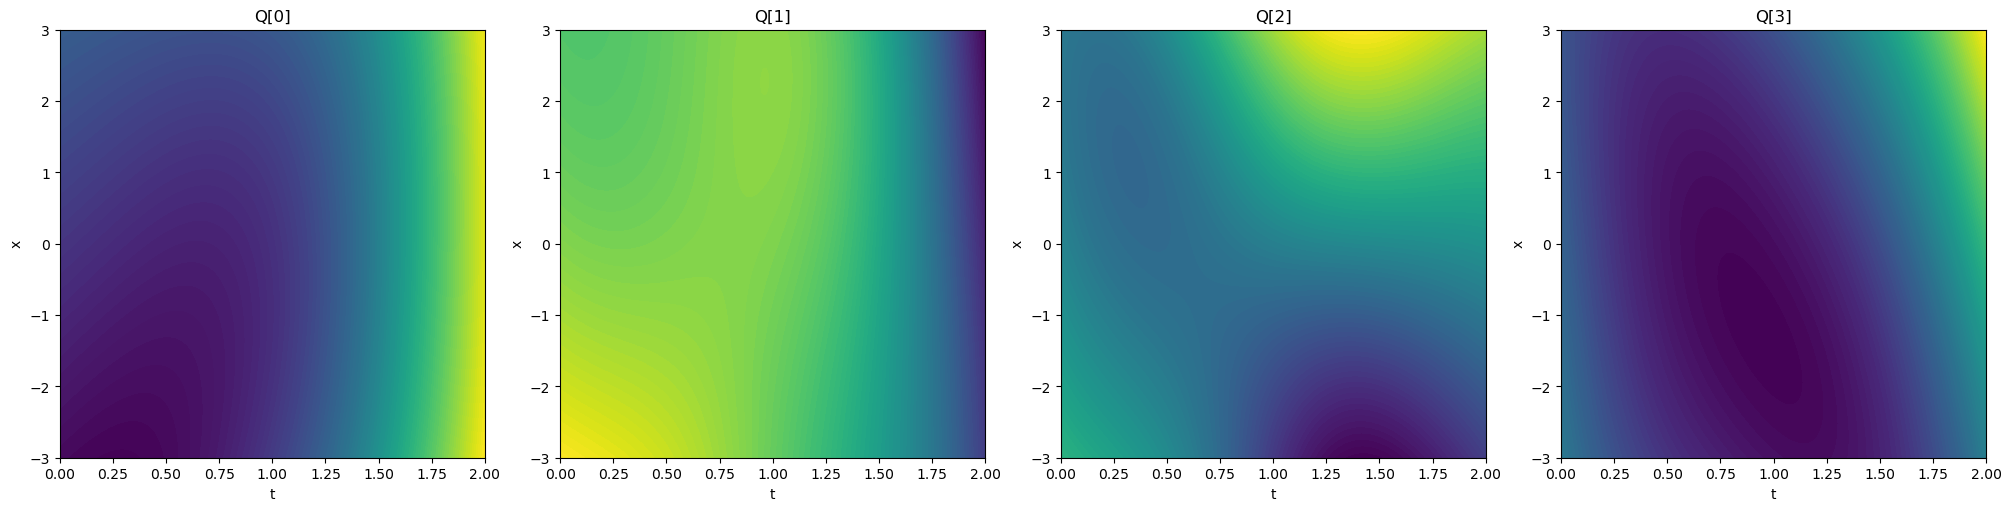

In [38]:
num_bases = 4
ncols = 4
nrows = int(np.ceil(num_bases / ncols))
T, X  = np.meshgrid(t_grid, x_grid, indexing="ij")

trunk_out = np.array(vmap(lambda x: model_trunk(x))(train_xt))  # (T*X, K)
trunk_3d = trunk_out.reshape(len(x_grid), len(t_grid), -1)       # (X, T, K)


fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)
axes = axes.flatten()

for k, ax in enumerate(axes):
    if k < num_bases:
        b = trunk_3d[:, :, k].T
        im  = ax.contourf(T, X, b, levels=100, cmap='viridis')
        ax.set_title(f"Q[{k}]")
        ax.set_xlabel("t")
        ax.set_ylabel("x")
    else:
        ax.axis("off")

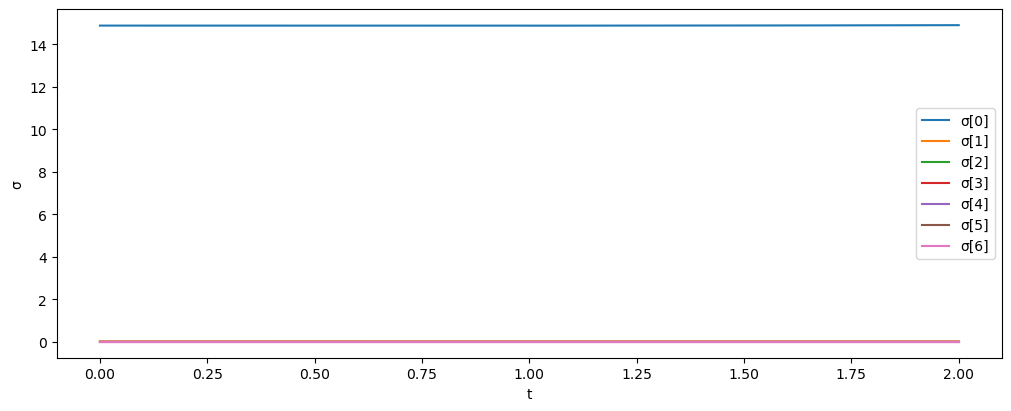

In [39]:
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

sv_history = np.zeros((len(t_grid), Q_sign.shape[2]))
for i in range(len(t_grid)):
    _, s, _ = la.svd(np.array(T_MAT_3d[i,:, :]), full_matrices=False)
    sv_history[i] = s

for k in range(Q_sign.shape[2]):
    ax.plot(t_grid, sv_history[:, k], label=f"σ[{k}]")

ax.set_xlabel("t")
ax.set_ylabel("σ")
ax.legend()

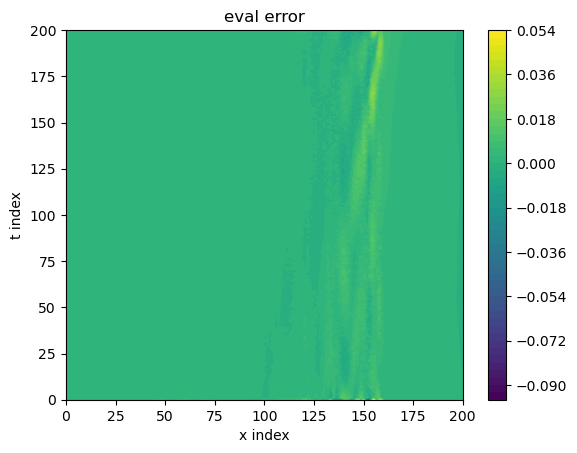

In [40]:
plt.figure()
plt.contourf(pred-truth, levels=50, cmap='viridis')
plt.xlabel('x index')
plt.ylabel('t index')
plt.colorbar()
plt.title('eval error')
plt.show()

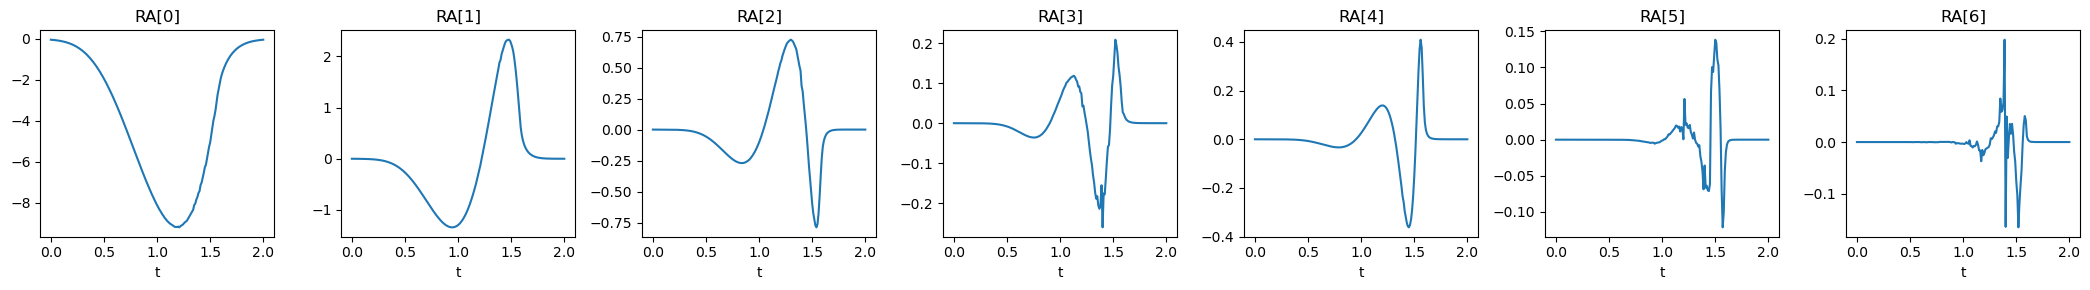

In [41]:
fig, axes = plt.subplots(1, Q_sign.shape[2], figsize=(3 * Q_sign.shape[2], 3))
for k in range(Q_sign.shape[2]):
    axes[k].plot(t_grid, RA_target[:, k, 0])
    axes[k].set_title(f"RA[{k}]")
    axes[k].set_xlabel("t")
plt.tight_layout()
plt.show()

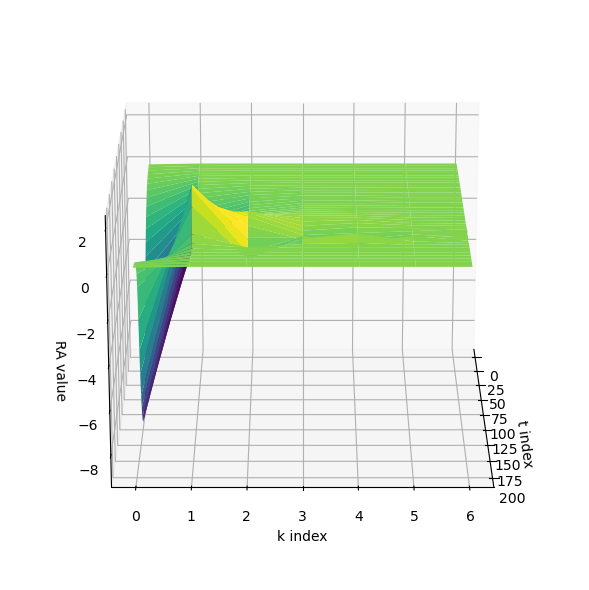

In [42]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
T_idx, K_idx = np.meshgrid(np.arange(RA_target.shape[0]), np.arange(RA_target.shape[1]), indexing='ij')
ax.plot_surface(T_idx, K_idx, RA_target[:, :, 0], cmap='viridis')
ax.set_xlabel('t index')
ax.set_ylabel('k index')
ax.set_zlabel('RA value')
ax.view_init(elev=20, azim=0)
plt.tight_layout()
plt.show()

In [43]:
# for k in range(6):
#     plt.plot(t_grid, RA_target_normed[:, k, 0], label=f"k={k}")
# plt.legend(); plt.show()

In [44]:
# find where the spike is
err = np.abs(pred - truth)
t_idx, x_idx = np.unravel_index(np.argmax(err), err.shape)
print(f"spike at t_idx={t_idx}, x_idx={x_idx}")
print(f"t={t_grid[t_idx]:.4f}, x={x_grid[x_idx]:.4f}")

# check Q_sign at that location
print("Q_sign[:,x_idx,:] around spike:")
print(Q_sign[max(0,t_idx-2):t_idx+3, x_idx, :])

# Run this diagnostic before anything else
overlap = Q_sign[t_idx].T @ Q_sign[t_idx - 1]
print(overlap)  # if this is ~I, your correction worked; if not, wrong Q_sign is being used

spike at t_idx=0, x_idx=152
t=0.0000, x=1.5600
Q_sign[:,x_idx,:] around spike:
[[-0.07131624  0.06119034  0.02626124 -0.00593739 -0.10363933 -0.00364234
  -0.02710113]
 [-0.07131691  0.06116633  0.02644396 -0.01417287 -0.10288261 -0.00061342
   0.03727024]
 [-0.07131748  0.06113831  0.02663761 -0.02167232 -0.10139838 -0.0027189
   0.07823258]]
[[ 9.99912381e-01  1.18641164e-02  5.84609760e-03 -5.58903639e-06
  -5.61580782e-06 -1.78508981e-06 -1.02466885e-07]
 [ 1.30316494e-02 -8.08263481e-01 -5.88672936e-01 -8.01672402e-04
   1.90314639e-03  5.28951874e-04 -1.95578723e-05]
 [ 2.24705390e-03 -5.85648358e-01  8.03996205e-01 -6.87242523e-02
  -7.41762072e-02 -1.93818416e-02 -5.62843707e-05]
 [ 1.64350873e-04 -4.62704599e-02  6.67744651e-02  6.68399855e-02
   9.55091774e-01  2.75350749e-01  7.86896620e-04]
 [ 1.60134587e-04 -3.79621238e-02  5.05326390e-02  9.95139897e-01
  -7.39981532e-02 -1.93032215e-03  1.68884115e-03]
 [ 7.32745457e-06 -1.91917690e-03  2.75791809e-03  1.26583045e-02
   

In [45]:
t0 = t_grid[0]
b_pred_t0 = model_branch(jnp.concatenate([test_params[0], jnp.array([t0])]))  # (K+1,)
b_true_t0 = RA_target_normed[0, :, 0]  # (K+1,) for sample 0
print("pred:", b_pred_t0)
print("true:", b_true_t0)
print("diff:", b_pred_t0 - b_true_t0)

NameError: name 'RA_target_normed' is not defined

In [ ]:
print("RA_scale at t=0:", RA_scale[0, :, 0])
print("RA_scale_jnp at t=0:", RA_scale_jnp[0])

RA_scale at t=0: [3.5773773  1.0099082  0.3820366  0.15005194 0.04500183]
RA_scale_jnp at t=0: 3.5773773


In [ ]:
for i in range(len(t_grid)):
    print(f"t={i} cond: {np.linalg.cond(T_MAT_3d[i]):.2e}")

t=0 cond: 1.15e+05
t=1 cond: 1.14e+05
t=2 cond: 1.14e+05
t=3 cond: 1.13e+05
t=4 cond: 1.13e+05
t=5 cond: 1.12e+05
t=6 cond: 1.11e+05
t=7 cond: 1.11e+05
t=8 cond: 1.10e+05
t=9 cond: 1.10e+05
t=10 cond: 1.10e+05
t=11 cond: 1.09e+05
t=12 cond: 1.09e+05
t=13 cond: 1.09e+05
t=14 cond: 1.09e+05
t=15 cond: 1.10e+05
t=16 cond: 1.10e+05
t=17 cond: 1.11e+05
t=18 cond: 1.12e+05
t=19 cond: 1.13e+05
t=20 cond: 1.14e+05
t=21 cond: 1.16e+05
t=22 cond: 1.17e+05
t=23 cond: 1.20e+05
t=24 cond: 1.22e+05
t=25 cond: 1.25e+05
t=26 cond: 1.28e+05
t=27 cond: 1.32e+05
t=28 cond: 1.36e+05
t=29 cond: 1.41e+05
t=30 cond: 1.46e+05
t=31 cond: 1.53e+05
t=32 cond: 1.60e+05
t=33 cond: 1.68e+05
t=34 cond: 1.77e+05
t=35 cond: 1.89e+05
t=36 cond: 2.02e+05
t=37 cond: 2.17e+05
t=38 cond: 2.35e+05
t=39 cond: 2.57e+05
t=40 cond: 2.84e+05
t=41 cond: 3.17e+05
t=42 cond: 3.59e+05
t=43 cond: 4.13e+05
t=44 cond: 4.85e+05
t=45 cond: 5.82e+05
t=46 cond: 7.16e+05
t=47 cond: 8.94e+05
t=48 cond: 1.09e+06
t=49 cond: 1.17e+06
t=50 cond:

In [ ]:
overlap = Q_smooth[0].T @ Q_smooth[1]
print(np.diag(overlap))  # if any entry is negative or far from 1, that's your spike

[0.9999995 1.        1.0000005 0.9999958 0.9999424]


In [ ]:
print(sv_history[0])  # singular values at t=0
print(sv_history[1])

[1.46593962e+01 2.51312196e-01 1.62729602e-02 1.48899946e-03
 1.27512074e-04]
[1.46616335e+01 2.50452518e-01 1.62864514e-02 1.55131973e-03
 1.28236075e-04]


In [47]:
NN_pred_test = vmap(predict_one)(test_params)
NN_pred_train = vmap(predict_one)(train_params)

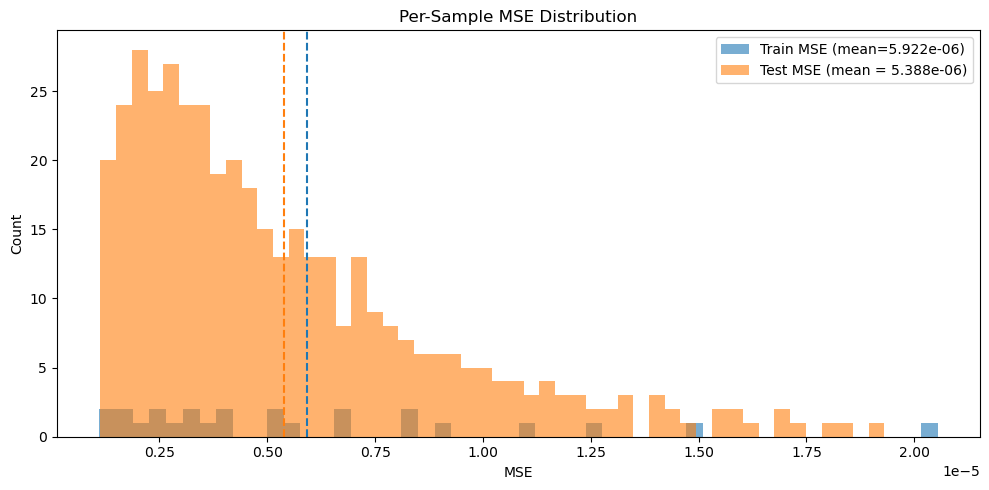

In [48]:
train_u_3d = train_u.reshape(train_u.shape[0], len(x_grid), len(t_grid)).transpose(0,2,1)  # (N, T, X)
test_u_3d  = test_u.reshape(test_u.shape[0],   len(x_grid), len(t_grid)).transpose(0,2,1)

train_mse_dataset = NN_pred_train - train_u_3d
test_mse_dataset  = NN_pred_test  - test_u_3d

train_mse_per_samp = jnp.array([float(jnp.mean(error**2)) for error in train_mse_dataset])
test_mse_per_samp = jnp.array([float(jnp.mean(error_test**2)) for error_test in test_mse_dataset])


fig, ax = plt.subplots(figsize=(10, 5))
bins = 50
ax.hist(train_mse_per_samp, bins=bins, alpha=0.6, label=f"Train MSE (mean={train_mse_per_samp.mean():.3e})")
ax.hist(test_mse_per_samp, bins = bins, alpha = 0.6, label=f"Test MSE (mean = {test_mse_per_samp.mean():.3e})")
ax.axvline(train_mse_per_samp.mean(),  linestyle='--', linewidth=1.5, color='C0')
ax.axvline(test_mse_per_samp.mean(),  linestyle='--', linewidth=1.5, color='C1')
ax.set_xlabel("MSE")
ax.set_ylabel("Count")
ax.set_title(f"Per-Sample MSE Distribution")
ax.legend()
plt.tight_layout()

In [ ]:
recon_smooth = np.einsum("txk,tkn->txn", Q_smooth, RA_target)
print("Q_smooth @ RA_target reconstruction error:", np.max(np.abs(recon_smooth - U_3d)))

Q_smooth @ RA_target reconstruction error: 0.19547137587895236


In [ ]:
recon_raw = np.einsum("txk,tkn->txn", Q_sign, R_sign @ A_check if False else
    np.array([R_sign[i] @ A_check[i] for i in range(len(t_grid))]))
print("Q_sign @ R_sign @ A reconstruction error:", np.max(np.abs(recon_raw - U_3d)))

Q_sign @ R_sign @ A reconstruction error: 0.19546078158370084


In [ ]:
for i in range(len(t_grid)):
    _, s, _ = la.svd(np.array(T_MAT_3d[i]), full_matrices=False)
    print(f"t={i} singular values: {s}")

t=0 singular values: [1.4659396e+01 2.5131220e-01 1.6272960e-02 1.4889995e-03 1.2751207e-04]
t=1 singular values: [1.46616335e+01 2.50452518e-01 1.62864514e-02 1.55131973e-03
 1.28236075e-04]
t=2 singular values: [1.4663856e+01 2.4959674e-01 1.6312599e-02 1.6153406e-03 1.2866748e-04]
t=3 singular values: [1.4666080e+01 2.4874489e-01 1.6351337e-02 1.6806860e-03 1.2982079e-04]
t=4 singular values: [1.4668291e+01 2.4789678e-01 1.6402673e-02 1.7474958e-03 1.3059369e-04]
t=5 singular values: [1.4670477e+01 2.4705181e-01 1.6466508e-02 1.8161882e-03 1.3074922e-04]
t=6 singular values: [1.4672668e+01 2.4621038e-01 1.6542591e-02 1.8858330e-03 1.3175147e-04]
t=7 singular values: [1.4674847e+01 2.4537194e-01 1.6630847e-02 1.9569315e-03 1.3231204e-04]
t=8 singular values: [1.4677015e+01 2.4453641e-01 1.6730979e-02 2.0291640e-03 1.3322216e-04]
t=9 singular values: [1.4679171e+01 2.4370368e-01 1.6842801e-02 2.1027050e-03 1.3396209e-04]
t=10 singular values: [1.4681303e+01 2.4287297e-01 1.6965924e-02

In [ ]:
for i in range(len(t_grid)):
    A_t = la.lstsq(np.array(T_MAT_3d[i]), U_3d[i])[0]
    res = np.max(np.abs(T_MAT_3d[i] @ A_t - U_3d[i]))
    print(f"t={i} lstsq residual: {res:.4e}")

t=0 lstsq residual: 2.3190e-07
t=1 lstsq residual: 1.5041e-07
t=2 lstsq residual: 3.2037e-07
t=3 lstsq residual: 3.6694e-07
t=4 lstsq residual: 4.2561e-07
t=5 lstsq residual: 4.9453e-07
t=6 lstsq residual: 5.6904e-07
t=7 lstsq residual: 6.5379e-07
t=8 lstsq residual: 7.4692e-07
t=9 lstsq residual: 8.4937e-07
t=10 lstsq residual: 9.6112e-07
t=11 lstsq residual: 1.0822e-06
t=12 lstsq residual: 1.2163e-06
t=13 lstsq residual: 1.3616e-06
t=14 lstsq residual: 1.5125e-06
t=15 lstsq residual: 1.6820e-06
t=16 lstsq residual: 1.8608e-06
t=17 lstsq residual: 2.0415e-06
t=18 lstsq residual: 2.2426e-06
t=19 lstsq residual: 2.4512e-06
t=20 lstsq residual: 2.6636e-06
t=21 lstsq residual: 2.8796e-06
t=22 lstsq residual: 3.0957e-06
t=23 lstsq residual: 3.3267e-06
t=24 lstsq residual: 3.5502e-06
t=25 lstsq residual: 3.7886e-06
t=26 lstsq residual: 4.0047e-06
t=27 lstsq residual: 4.2282e-06
t=28 lstsq residual: 4.4778e-06
t=29 lstsq residual: 4.7088e-06
t=30 lstsq residual: 4.9621e-06
t=31 lstsq residua